# Vertical aggregation

Compute vertical mean, min, and max on 3D dfsu data, collapsing layered data to 2D.

In [1]:
import matplotlib.pyplot as plt
import mikeio

## Read 3D data

We use the Øresund sigma-z test file with temperature and salinity.

In [3]:
ds = mikeio.read("../tests/testdata/oresund_sigma_z.dfsu", time=0)
ds

<mikeio.Dataset>
title: 3D volume series
dims: (element:17118)
time: 1997-09-15 21:00:00 (time-invariant)
geometry: Dfsu3DSigmaZ (17118 elements, 12042 nodes)
items:
  0:  Temperature <Temperature> (degree Celsius)
  1:  Salinity <Salinity> (PSU)

## Vertical mean

Thickness-weighted vertical mean collapses 3D geometry to 2D.

In [4]:
ds_mean = ds.mean(axis="z")
ds_mean

<mikeio.Dataset>
title: 3D volume series
dims: (element:3700)
time: 1997-09-15 21:00:00 (time-invariant)
geometry: Dfsu2D (3700 elements, 2090 nodes)
items:
  0:  Temperature <Temperature> (degree Celsius)
  1:  Salinity <Salinity> (PSU)

## Compare original, mean, min, max

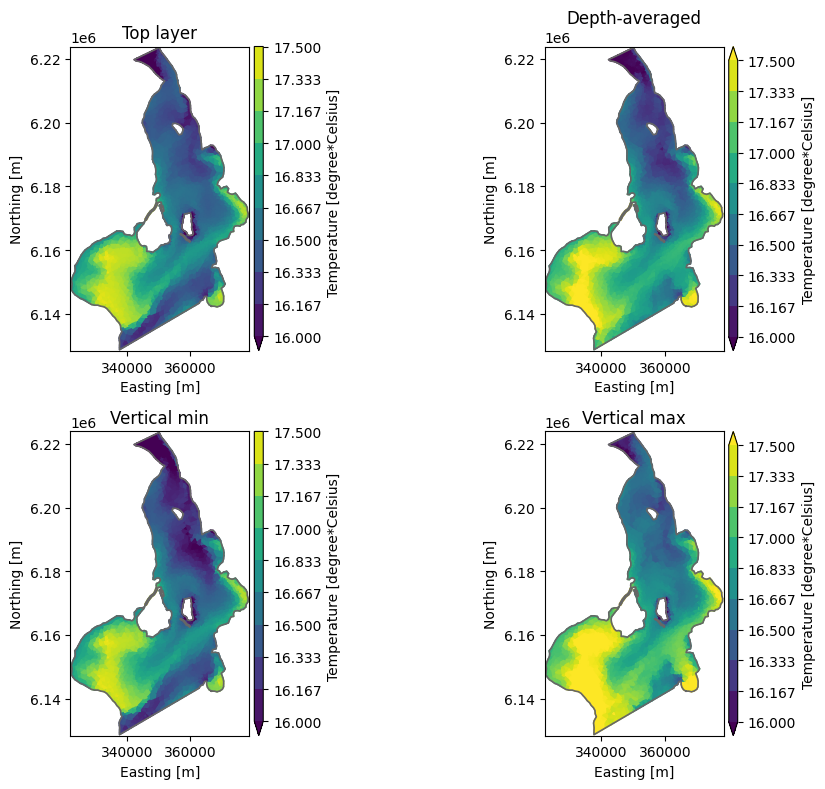

In [ ]:
da = ds["Temperature"]
da_mean = da.mean(axis="z")
da_min = da.min(axis="z")
da_max = da.max(axis="z")

vmin = 16
vmax = 17.5

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
da.sel(layers="top").plot(ax=axes[0, 0], title="Top layer", vmin=vmin, vmax=vmax)
da_mean.plot(ax=axes[0, 1], title="Depth-averaged", vmin=vmin, vmax=vmax)
da_min.plot(ax=axes[1, 0], title="Vertical min", vmin=vmin, vmax=vmax)
da_max.plot(ax=axes[1, 1], title="Vertical max", vmin=vmin, vmax=vmax)
fig.tight_layout();

## Subset layers first

Select specific layers before aggregating. E.g. mean of the top 3 layers:

In [ ]:
da_top3 = da.sel(layers=[-1, -2, -3])
da_top3_mean = da_top3.mean(axis="z")
da_top3_mean.plot(title="Mean temperature (top 3 layers)");